# Полный EDA — четыре домена opendata

**Цель:** объединённый датасет: купание (`supluskoha`), водопровод (`veevark`), бассейны/СПА (`basseinid`), источники питьевой воды (`joogivesi` / joogiveeallikas). Соответствует `load_all()` по умолчанию в `data_loader`.

**Перед запуском:** при отсутствии XML выполните `python src/data_loader.py` или дождитесь скачивания в первой ячейке (нужен интернет).

**Colab:** [colab_quickstart.ipynb](colab_quickstart.ipynb); при необходимости `%cd /content/water-quality-ee`.

In [1]:
# Рекомендуется: pip install -e . из корня репозитория (тот же Python, что у kernel)
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

def _project_root() -> Path:
    spec = importlib.util.find_spec('data_loader')
    if spec is not None and getattr(spec, 'origin', None):
        cand = Path(spec.origin).resolve().parent.parent
        if (cand / 'data' / 'raw').is_dir() or (cand / 'src' / 'data_loader.py').is_file():
            return cand
    env = os.environ.get('WATER_QUALITY_EE_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    cwd = Path.cwd().resolve()
    try:
        r = subprocess.run(
            ['git', 'rev-parse', '--show-toplevel'],
            cwd=cwd, capture_output=True, text=True, timeout=15,
        )
        if r.returncode == 0 and r.stdout.strip():
            p = Path(r.stdout.strip()).resolve()
            if (p / 'src' / 'data_loader.py').is_file():
                return p
    except (FileNotFoundError, OSError, subprocess.TimeoutExpired):
        pass
    for root in [cwd, *list(cwd.parents)[:28]]:
        if (root / 'src' / 'data_loader.py').is_file():
            return root
    raise RuntimeError('См. 01: pip install -e . или WATER_QUALITY_EE_ROOT на путь, видимый этому kernel.')

if importlib.util.find_spec('data_loader') is None:
    _src = str(_project_root() / 'src')
    if _src not in sys.path:
        sys.path.insert(0, _src)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_all, save_combined_csv

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## 1. Загрузка и сохранение сырого объединённого CSV

In [ ]:
df = load_all(use_cache=True)  # + joogivesi (joogiveeallika_veeproovid)
print(df.shape)
print(df['domain'].value_counts())
save_combined_csv(df, 'raw_combined.csv')

[data_loader] Скачиваю supluskoha за 2026…


[data_loader] Год 2026 недоступен: 404 Client Error: Not Found for url: https://vtiav.sm.ee/index.php/opendata/supluskoha_veeproovid_2026.xml
[data_loader] Кэш: supluskoha_2025.xml
[data_loader] Кэш: supluskoha_2024.xml
[data_loader] Кэш: supluskoha_2023.xml
[data_loader] Кэш: supluskoha_2022.xml
[data_loader] Кэш: supluskoha_2021.xml
[data_loader] supluskoha: 4031 проб, 4031 с известным статусом
[data_loader] Кэш: veevark_2026.xml
[data_loader] Кэш: veevark_2025.xml
[data_loader] Кэш: veevark_2024.xml
[data_loader] Кэш: veevark_2023.xml


[data_loader] Кэш: veevark_2022.xml
[data_loader] Кэш: veevark_2021.xml


[data_loader] veevark: 34563 проб, 34563 с известным статусом
[data_loader] Кэш: basseinid_2026.xml
[data_loader] Кэш: basseinid_2025.xml
[data_loader] Кэш: basseinid_2024.xml
[data_loader] Кэш: basseinid_2023.xml
[data_loader] Кэш: basseinid_2022.xml
[data_loader] Кэш: basseinid_2021.xml


[data_loader] basseinid: 30477 проб, 30477 с известным статусом
[data_loader] Кэш: joogivesi_2026.xml
[data_loader] Кэш: joogivesi_2025.xml
[data_loader] Кэш: joogivesi_2024.xml
[data_loader] Кэш: joogivesi_2023.xml
[data_loader] Кэш: joogivesi_2022.xml
[data_loader] Кэш: joogivesi_2021.xml
[data_loader] joogivesi: 376 проб, 376 с известным статусом
[data_loader] Итого: 69447 проб из 4 доменов


[county_infer] Заполнено county не из XML: 952 строк; распределение county_source:
county_source
unknown     68495
override      952
(69447, 31)
domain
veevark       34563
basseinid     30477
supluskoha     4031
joogivesi       376
Name: count, dtype: int64


[data_loader] Сохранено: /workspace/data/processed/raw_combined.csv


PosixPath('/workspace/data/processed/raw_combined.csv')

## 1b. Важно: дедупликация мест по нормализованному имени

> **Это обязательный шаг при любом анализе по местам.** Пропустить его — значит получить ложные дубли в статистике.

### Проблема: Terviseamet переименовывает места между годами

В opendata XML одно и то же физическое место может получать разные строки в поле `location`:

| Год | Название в XML |
|---|---|
| 2021 | `Harku järve supluskoht` |
| 2025 | `Harku järve rand` |

| 2022 | `Haaslava küla veevärk` |
| 2026 | `Haaslava küla ühisveevärk` |

Если агрегировать по сырому `location`, место выглядит как **два разных объекта**: один с пробой 2021 года, второй — 2025. В диагностике такое место появляется как «не проверялось 4 года», хотя мониторинг идёт нормально.

**Обнаружено:** 38 подобных пар в снимке апреля 2026 (10 купальных мест, 24 водопроводных, 4 бассейна).

### Решение: `normalize_location()` и `location_key`

`data_loader.load_domain()` автоматически добавляет столбец `location_key` — нормализованное имя:
- нижний регистр
- убраны суффиксы: `supluskoht`, `rand`, `supluskoha`, `veevärk`, `ühisveevärk`, `veevõrk`
- нормализованы дефисы, лишние пробелы, точки с запятой

```python
from data_loader import normalize_location
normalize_location('Harku järve supluskoht')  # → 'harku järve'
normalize_location('Harku järve rand')        # → 'harku järve'  ← то же место!
```

**Правило:** при подсчёте уникальных мест, при группировке по месту, при поиске «проблемных локаций» — **всегда используйте `location_key`, а не `location`**.

In [3]:
from data_loader import normalize_location

# Проверяем что location_key появился после load_all()
print("location_key в датасете:", "location_key" in df.columns)

# Считаем уникальные места ДО и ПОСЛЕ нормализации
n_raw = df.groupby(["domain", "location"]).ngroups
n_norm = df.groupby(["domain", "location_key"]).ngroups
print(f"Уникальных мест по сырому location: {n_raw}")
print(f"Уникальных мест по location_key:    {n_norm}")
print(f"Потенциальных дублей (переименования): {n_raw - n_norm}")

# Показываем примеры переименований
dups = (
    df.groupby(["domain", "location_key"])["location"]
    .nunique()
    .reset_index()
    .rename(columns={"location": "n_names"})
)
dups = dups[dups["n_names"] > 1].copy()
print(f"\nГрупп с несколькими именами: {len(dups)}")
if len(dups) > 0:
    for _, row in dups.head(6).iterrows():
        names = df[
            (df["domain"] == row["domain"]) & (df["location_key"] == row["location_key"])
        ]["location"].unique()
        dates = df[
            (df["domain"] == row["domain"]) & (df["location_key"] == row["location_key"])
        ].groupby("location")["sample_date"].max()
        print(f"\n  [{row['domain']}] key='{row['location_key']}':")
        for name in names:
            print(f"    '{name}'  последняя проба: {str(dates.get(name, '?'))[:10]}")

location_key в датасете: True
Уникальных мест по сырому location: 2232
Уникальных мест по location_key:    2194
Потенциальных дублей (переименования): 38

Групп с несколькими именами: 38

  [basseinid] key='haljala lasteaed pesapuu bassein':
    'Haljala Lasteaed Pesapuu bassein'  последняя проба: 2026-03-16
    'Haljala lasteaed Pesapuu bassein'  последняя проба: 2023-12-28

  [basseinid] key='kernu keller spa bassein':
    'Kernu Keller Spa bassein'  последняя проба: 2026-01-30
    'Kernu Keller Spa, bassein'  последняя проба: 2023-11-23

  [basseinid] key='kernu keller spa mullivann':
    'Kernu Keller Spa mullivann'  последняя проба: 2026-01-30
    'Kernu Keller Spa, mullivann'  последняя проба: 2023-11-23

  [basseinid] key='kesklinna lastepolikliiniku a bassein':
    'Kesklinna Lastepolikliiniku A bassein'  последняя проба: 2025-12-08
    'Kesklinna Lastepolikliiniku A-bassein'  последняя проба: 2021-12-06

  [basseinid] key='külmavee bassein':
    'külmavee bassein'  последняя п

## 2. Целевая переменная и известный статус

In [4]:
known = df.dropna(subset=['compliant'])
print('С известным compliant:', len(known))
print(known['compliant'].value_counts())
print(known['compliant'].value_counts(normalize=True).round(3))

С известным compliant: 69447
compliant
1    61092
0     8355
Name: count, dtype: int64
compliant
1    0.88
0    0.12
Name: proportion, dtype: float64


## 3. Числовые признаки: пропуски и распределения по доменам

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'compliant' in num_cols:
    num_cols.remove('compliant')
miss = df[num_cols].isna().mean().sort_values(ascending=False)
print('Доля пропусков (топ-15):')
print(miss.head(15).round(3))

Доля пропусков (топ-15):
transparency         1.000
sulfates             0.973
chlorides            0.972
fluoride             0.969
nitrites             0.966
manganese            0.926
iron                 0.734
oxidizability        0.717
pseudomonas          0.713
combined_chlorine    0.713
colonies_37c         0.712
staphylococci        0.712
free_chlorine        0.711
nitrates             0.685
ammonium             0.655
dtype: float64


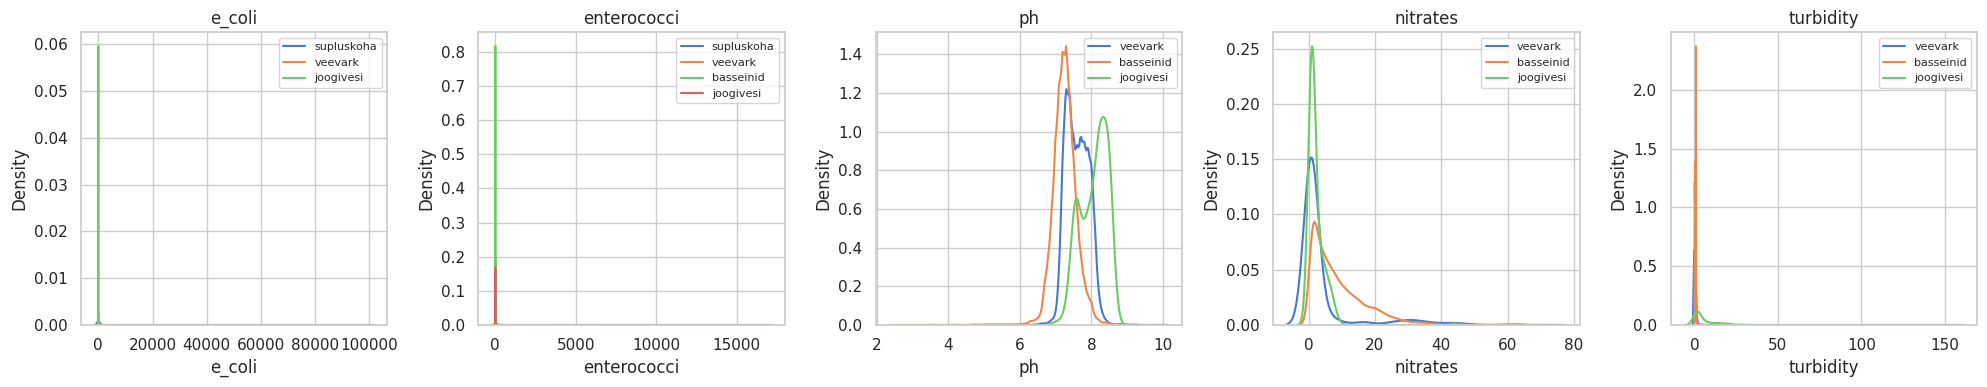

In [6]:
plot_cols = [c for c in ['e_coli', 'enterococci', 'ph', 'nitrates', 'turbidity'] if c in df.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        for dom in df['domain'].dropna().unique():
            subset = df.loc[df['domain'] == dom, col].dropna()
            if len(subset) > 0:
                sns.kdeplot(subset, ax=ax, label=dom, warn_singular=False)
        ax.set_title(col)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Нарушения по уездам (топ-15)

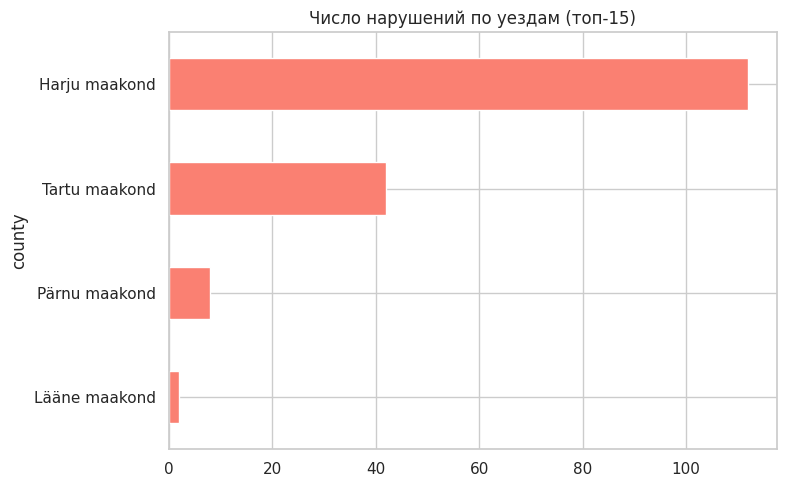

In [7]:
viol = known[known['compliant'] == 0]
if 'county' in viol.columns and len(viol) > 0:
    top = viol['county'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    top.sort_values().plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Число нарушений по уездам (топ-15)')
    plt.tight_layout()
    plt.show()
else:
    print('Нет данных по уездам или нарушений.')

## 5. Время: пробы по годам

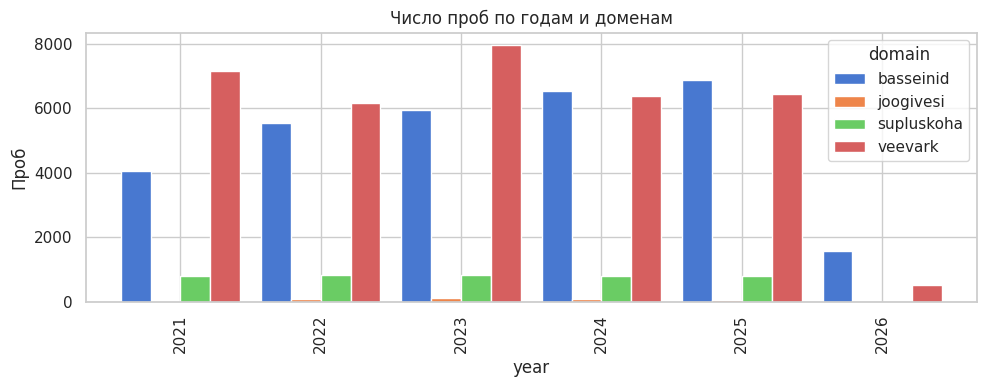

In [8]:
if 'sample_date' in df.columns:
    df = df.copy()
    df['year'] = pd.to_datetime(df['sample_date'], errors='coerce').dt.year
    vc = df.groupby(['year', 'domain']).size().unstack(fill_value=0)
    vc.plot(kind='bar', figsize=(10, 4), width=0.85)
    plt.title('Число проб по годам и доменам')
    plt.ylabel('Проб')
    plt.tight_layout()
    plt.show()

## 6. Корреляции (числовые столбцы с достаточным заполнением)

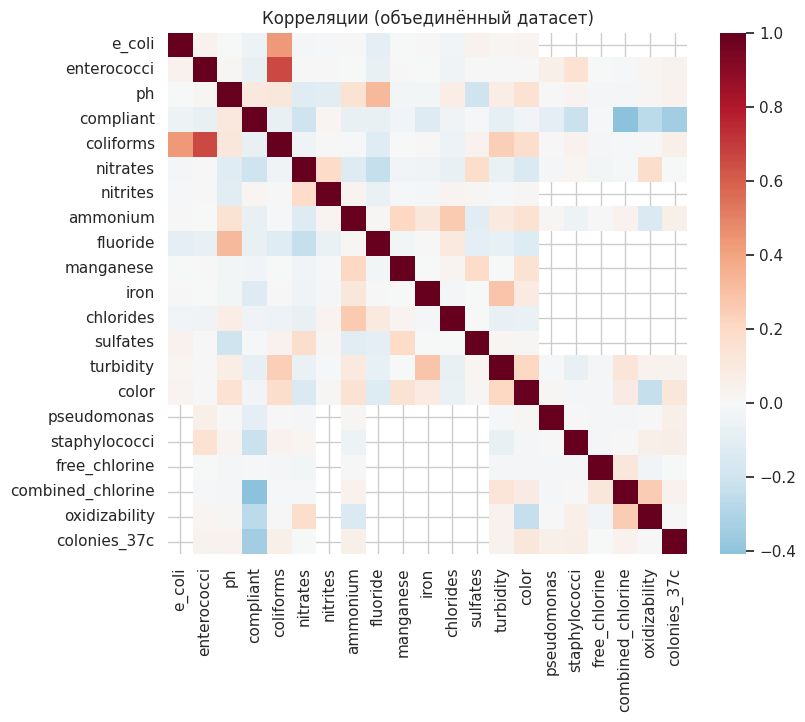

In [ ]:
labeled = known.copy()
num = labeled.select_dtypes(include=[np.number]).columns.tolist()
keep = [c for c in num if labeled[c].notna().sum() > 100]
if 'compliant' not in keep and 'compliant' in labeled.columns:
    keep.append('compliant')
if len(keep) > 2:
    corr = labeled[keep].corr()
    fig, ax = plt.subplots(figsize=(max(8, len(keep) * 0.4), max(6, len(keep) * 0.35)))
    sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Корреляции (объединённый датасет)')
    plt.tight_layout()
    plt.show()
else:
    print('Недостаточно числовых столбцов для корреляций.')

## 7. Инсайты для отчёта

### Объём и доли классов

- **Всего проб:** 38 594 (supluskoha: 4 031 / veevark: 34 563)
- **Нарушений:** 2 739 (7.1%) — одинаковая доля в обоих доменах (~7.3% / ~7.1%)
- Дисбаланс классов 1:13 → обязателен `class_weight='balanced'`

### Пропуски по доменам

| Параметр | supluskoha | veevark |
|----------|-----------|---------|
| e_coli | 9% | 23% |
| enterococci | 9% | 74% |
| ph | **100%** | 65% |
| transparency | **100%** | 100% |
| iron | — | 47% |
| nitrates, chlorides, sulfates | — | 93–95% |

pH и transparency недоступны в opendata XML supluskoha. Редкие химические параметры (нитраты, хлориды) измеряются лишь в целевых проверках veevark.

### Динамика по годам

- **2024** выделяется: 10.3% нарушений — максимальная доля за весь период
- **2022** — лучший год: 4.3% нарушений

### Параметры с наибольшей частотой нарушений нормы

1. **Марганец** (Mn): 6.7% проб превышают 0.05 мг/л
2. **Хлориды**: 5.8% превышают 250 мг/л
3. **Фторид**: 3.0% превышают 1.5 мг/л
4. **Железо**: 2.2% превышают 0.2 мг/л (411 нарушений — рекорд по абсолюту)

### Приоритет метрики

**Recall по классу 0** — не пропустить опасную воду. False Negative (сказали «норма», а вода загрязнена) — худший исход. Даже 30 пропущенных нарушений из 548 в test-set (5.5%) — это реальный риск для здоровья.